In [99]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from lightgbm import LGBMRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [100]:
df = pd.read_csv(r'C:\Users\ASUS\OneDrive\文档\SEMESTER4\rideshare_kaggle.csv')
df.head()

,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,12/16/2018 9:30,America/New_York,Haymarket Square,North Station,Lyft,...,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,11/27/2018 2:00,America/New_York,Haymarket Square,North Station,Lyft,...,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,11/28/2018 1:00,America/New_York,Haymarket Square,North Station,Lyft,...,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,11/30/2018 4:53,America/New_York,Haymarket Square,North Station,Lyft,...,0.0000,1543507200,34.67,1543550400,45.03,1543510800,30.30,1543550400,38.53,1543510800
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,11/29/2018 3:49,America/New_York,Haymarket Square,North Station,Lyft,...,0.0001,1543420800,33.10,1543402800,42.18,1543420800,29.11,1543392000,35.75,1543420800


In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           693071 non-null  str    
 1   timestamp                    693071 non-null  float64
 2   hour                         693071 non-null  int64  
 3   day                          693071 non-null  int64  
 4   month                        693071 non-null  int64  
 5   datetime                     693071 non-null  str    
 6   timezone                     693071 non-null  str    
 7   source                       693071 non-null  str    
 8   destination                  693071 non-null  str    
 9   cab_type                     693071 non-null  str    
 10  product_id                   693071 non-null  str    
 11  name                         693071 non-null  str    
 12  price                        637976 non-null  float64
 13  distance  

In [102]:
df.describe()

,timestamp,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
count,6.930710e+05,693071.000000,693071.000000,693071.000000,637976.000000,693071.000000,693071.000000,693071.000000,693071.000000,693071.000000,...,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05
mean,1.544049e+09,11.619137,17.794365,11.586684,16.545125,2.189430,1.013870,42.338172,-71.066151,39.584388,...,0.037374,1.544044e+09,33.457774,1.544042e+09,45.261313,1.544047e+09,29.731002,1.544048e+09,41.997343,1.544048e+09
std,7.056569e+05,6.948114,9.982286,0.492429,9.324359,1.138937,0.091641,0.047840,0.020302,6.726084,...,0.055214,6.912028e+05,6.467224,6.901954e+05,5.645046,6.901353e+05,7.110494,6.871862e+05,6.936841,6.910777e+05
min,1.543204e+09,0.000000,1.000000,11.000000,2.500000,0.020000,1.000000,42.214800,-71.105400,18.910000,...,0.000000,1.543162e+09,15.630000,1.543122e+09,33.510000,1.543154e+09,11.810000,1.543136e+09,28.950000,1.543187e+09
25%,1.543444e+09,6.000000,13.000000,11.000000,9.000000,1.280000,1.000000,42.350300,-71.081000,36.450000,...,0.000000,1.543421e+09,30.170000,1.543399e+09,42.570000,1.543439e+09,27.760000,1.543399e+09,36.570000,1.543439e+09
50%,1.543737e+09,12.000000,17.000000,12.000000,13.500000,2.160000,1.000000,42.351900,-71.063100,40.490000,...,0.000400,1.543770e+09,34.240000,1.543727e+09,44.680000,1.543788e+09,30.130000,1.543745e+09,40.950000,1.543788e+09
75%,1.544828e+09,18.000000,28.000000,12.000000,22.500000,2.920000,1.000000,42.364700,-71.054200,43.580000,...,0.091600,1.544807e+09,38.880000,1.544789e+09,46.910000,1.544814e+09,35.710000,1.544789e+09,44.120000,1.544818e+09
max,1.550000e+09,23.000000,30.000000,12.000000,97.500000,7.860000,3.000000,42.366100,-71.033000,57.220000,...,0.145900,1.545152e+09,43.100000,1.545192e+09,57.870000,1.545109e+09,40.050000,1.545134e+09,57.200000,1.545109e+09


In [103]:
df.isnull().sum()

id                                 0
timestamp                          0
hour                               0
day                                0
month                              0
datetime                           0
timezone                           0
source                             0
destination                        0
cab_type                           0
product_id                         0
name                               0
price                          55095
distance                           0
surge_multiplier                   0
latitude                           0
longitude                          0
temperature                        0
apparentTemperature                0
short_summary                      0
long_summary                       0
precipIntensity                    0
precipProbability                  0
humidity                           0
windSpeed                          0
windGust                           0
windGustTime                       0
v

In [104]:
duplikat = df.duplicated().sum()
print("Duplikat : ",duplikat)

Duplikat :  0


In [105]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])
df = df.reset_index(drop=True)

In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 637976 entries, 0 to 637975
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           637976 non-null  str    
 1   timestamp                    637976 non-null  float64
 2   hour                         637976 non-null  int64  
 3   day                          637976 non-null  int64  
 4   month                        637976 non-null  int64  
 5   datetime                     637976 non-null  str    
 6   timezone                     637976 non-null  str    
 7   source                       637976 non-null  str    
 8   destination                  637976 non-null  str    
 9   cab_type                     637976 non-null  str    
 10  product_id                   637976 non-null  str    
 11  name                         637976 non-null  str    
 12  price                        637976 non-null  float64
 13  distance  

In [107]:
df.isnull().sum()

id                             0
timestamp                      0
hour                           0
day                            0
month                          0
datetime                       0
timezone                       0
source                         0
destination                    0
cab_type                       0
product_id                     0
name                           0
price                          0
distance                       0
surge_multiplier               0
latitude                       0
longitude                      0
temperature                    0
apparentTemperature            0
short_summary                  0
long_summary                   0
precipIntensity                0
precipProbability              0
humidity                       0
windSpeed                      0
windGust                       0
windGustTime                   0
visibility                     0
temperatureHigh                0
temperatureHighTime            0
temperatur

In [108]:
df.head()

,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,12/16/2018 9:30,America/New_York,Haymarket Square,North Station,Lyft,...,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,11/27/2018 2:00,America/New_York,Haymarket Square,North Station,Lyft,...,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,11/28/2018 1:00,America/New_York,Haymarket Square,North Station,Lyft,...,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,11/30/2018 4:53,America/New_York,Haymarket Square,North Station,Lyft,...,0.0000,1543507200,34.67,1543550400,45.03,1543510800,30.30,1543550400,38.53,1543510800
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,11/29/2018 3:49,America/New_York,Haymarket Square,North Station,Lyft,...,0.0001,1543420800,33.10,1543402800,42.18,1543420800,29.11,1543392000,35.75,1543420800


In [109]:
drop_cols = [
'id','timestamp','datetime','timezone','product_id','source','destination',
'short_summary','long_summary','icon','visibility.1',
'windGustTime','temperatureHighTime','temperatureLowTime',
'apparentTemperatureHighTime','apparentTemperatureLowTime',
'sunriseTime','sunsetTime','uvIndexTime',
'temperatureMin','temperatureMinTime','temperatureMax','temperatureMaxTime',
'apparentTemperatureMin','apparentTemperatureMinTime',
'apparentTemperatureMax','apparentTemperatureMaxTime'
]

df = df.drop(columns=drop_cols, errors='ignore')

In [110]:
df.head()

,hour,day,month,cab_type,name,price,distance,surge_multiplier,latitude,longitude,...,apparentTemperatureHigh,apparentTemperatureLow,dewPoint,pressure,windBearing,cloudCover,uvIndex,ozone,moonPhase,precipIntensityMax
0,9,16,12,Lyft,Shared,5.0,0.44,1.0,42.2148,-71.033,...,37.95,27.39,32.70,1021.98,57,0.72,0,303.8,0.30,0.1276
1,2,27,11,Lyft,Lux,11.0,0.44,1.0,42.2148,-71.033,...,43.92,36.20,41.83,1003.97,90,1.00,0,291.1,0.64,0.1300
2,1,28,11,Lyft,Lyft,7.0,0.44,1.0,42.2148,-71.033,...,44.12,29.11,31.10,992.28,240,0.03,0,315.7,0.68,0.1064
3,4,30,11,Lyft,Lux Black XL,26.0,0.44,1.0,42.2148,-71.033,...,38.53,26.20,26.64,1013.73,310,0.00,0,291.1,0.75,0.0000
4,3,29,11,Lyft,Lyft XL,9.0,0.44,1.0,42.2148,-71.033,...,35.75,30.29,28.61,998.36,303,0.44,0,347.7,0.72,0.0001


In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 637976 entries, 0 to 637975
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   hour                     637976 non-null  int64  
 1   day                      637976 non-null  int64  
 2   month                    637976 non-null  int64  
 3   cab_type                 637976 non-null  str    
 4   name                     637976 non-null  str    
 5   price                    637976 non-null  float64
 6   distance                 637976 non-null  float64
 7   surge_multiplier         637976 non-null  float64
 8   latitude                 637976 non-null  float64
 9   longitude                637976 non-null  float64
 10  temperature              637976 non-null  float64
 11  apparentTemperature      637976 non-null  float64
 12  precipIntensity          637976 non-null  float64
 13  precipProbability        637976 non-null  float64
 14  humidity       

In [112]:
df = pd.get_dummies(df, columns=['cab_type', 'name'], drop_first=True)

In [113]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 637976 entries, 0 to 637975
Data columns (total 40 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   hour                     637976 non-null  int64  
 1   day                      637976 non-null  int64  
 2   month                    637976 non-null  int64  
 3   price                    637976 non-null  float64
 4   distance                 637976 non-null  float64
 5   surge_multiplier         637976 non-null  float64
 6   latitude                 637976 non-null  float64
 7   longitude                637976 non-null  float64
 8   temperature              637976 non-null  float64
 9   apparentTemperature      637976 non-null  float64
 10  precipIntensity          637976 non-null  float64
 11  precipProbability        637976 non-null  float64
 12  humidity                 637976 non-null  float64
 13  windSpeed                637976 non-null  float64
 14  windGust       

In [114]:
df.head()

,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,...,name_Lux,name_Lux Black,name_Lux Black XL,name_Lyft,name_Lyft XL,name_Shared,name_UberPool,name_UberX,name_UberXL,name_WAV
0,9,16,12,5.0,0.44,1.0,42.2148,-71.033,42.34,37.12,...,False,False,False,False,False,True,False,False,False,False
1,2,27,11,11.0,0.44,1.0,42.2148,-71.033,43.58,37.35,...,True,False,False,False,False,False,False,False,False,False
2,1,28,11,7.0,0.44,1.0,42.2148,-71.033,38.33,32.93,...,False,False,False,True,False,False,False,False,False,False
3,4,30,11,26.0,0.44,1.0,42.2148,-71.033,34.38,29.63,...,False,False,True,False,False,False,False,False,False,False
4,3,29,11,9.0,0.44,1.0,42.2148,-71.033,37.44,30.88,...,False,False,False,False,True,False,False,False,False,False


In [115]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [116]:
df.head()

,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,...,name_Lux,name_Lux Black,name_Lux Black XL,name_Lyft,name_Lyft XL,name_Shared,name_UberPool,name_UberX,name_UberXL,name_WAV
0,9,16,12,5.0,0.44,1.0,42.2148,-71.033,42.34,37.12,...,0,0,0,0,0,1,0,0,0,0
1,2,27,11,11.0,0.44,1.0,42.2148,-71.033,43.58,37.35,...,1,0,0,0,0,0,0,0,0,0
2,1,28,11,7.0,0.44,1.0,42.2148,-71.033,38.33,32.93,...,0,0,0,1,0,0,0,0,0,0
3,4,30,11,26.0,0.44,1.0,42.2148,-71.033,34.38,29.63,...,0,0,1,0,0,0,0,0,0,0
4,3,29,11,9.0,0.44,1.0,42.2148,-71.033,37.44,30.88,...,0,0,0,0,1,0,0,0,0,0


In [117]:
x = df.drop('price', axis=1)
y = df['price']

In [118]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [119]:
df.head()

,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,...,name_Lux,name_Lux Black,name_Lux Black XL,name_Lyft,name_Lyft XL,name_Shared,name_UberPool,name_UberX,name_UberXL,name_WAV
0,9,16,12,5.0,0.44,1.0,42.2148,-71.033,42.34,37.12,...,0,0,0,0,0,1,0,0,0,0
1,2,27,11,11.0,0.44,1.0,42.2148,-71.033,43.58,37.35,...,1,0,0,0,0,0,0,0,0,0
2,1,28,11,7.0,0.44,1.0,42.2148,-71.033,38.33,32.93,...,0,0,0,1,0,0,0,0,0,0
3,4,30,11,26.0,0.44,1.0,42.2148,-71.033,34.38,29.63,...,0,0,1,0,0,0,0,0,0,0
4,3,29,11,9.0,0.44,1.0,42.2148,-71.033,37.44,30.88,...,0,0,0,0,1,0,0,0,0,0


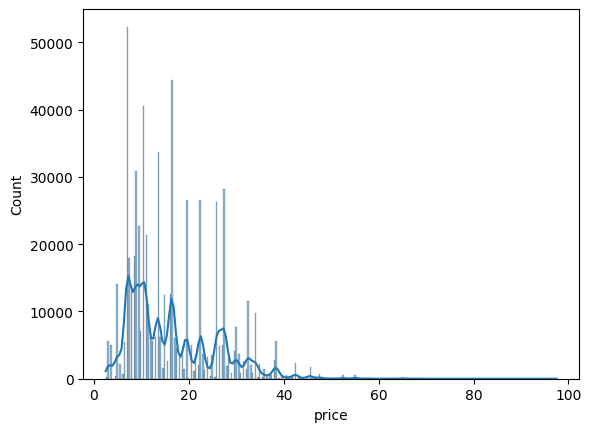

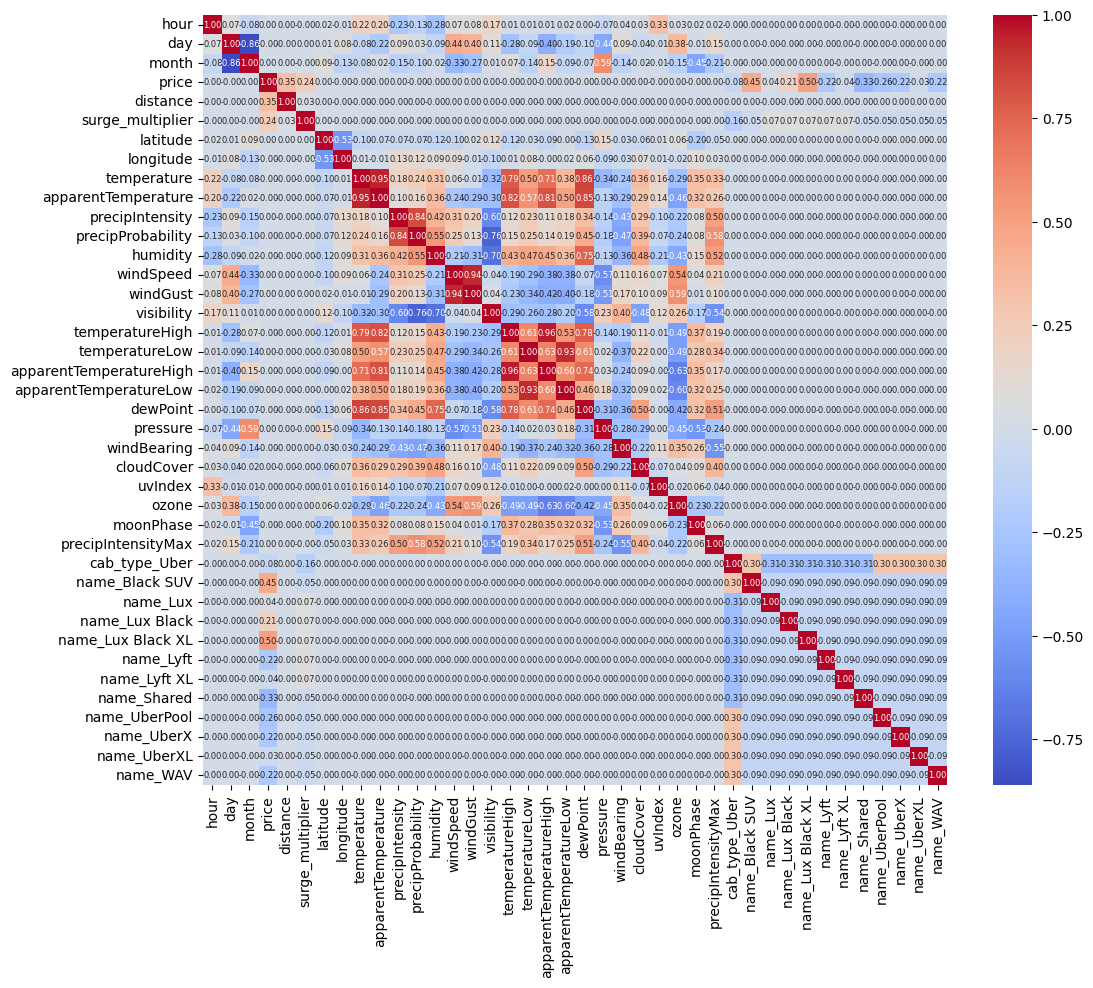

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

# distribusi harga
sns.histplot(df['price'], kde=True)
plt.show()

# korelasi dengan angka
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 6})
plt.show()

In [121]:
from sklearn.model_selection import train_test_split

x_train_70, x_test_30, y_train_70, y_test_30 = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [122]:
x_train_80, x_test_20, y_train_80, y_test_20 = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [123]:
x_train_90, x_test_10, y_train_90, y_test_10 = train_test_split(
    x, y, test_size=0.1, random_state=42
)

In [124]:
print("70:30", x_train_70.shape, x_test_30.shape)
print("80:20", x_train_80.shape, x_test_20.shape)
print("90:10", x_train_90.shape, x_test_10.shape)

70:30 (446583, 39) (191393, 39)
80:20 (510380, 39) (127596, 39)
90:10 (574178, 39) (63798, 39)


In [131]:
splits = {
    "70:30": 0.3,
    "80:20": 0.2,
    "90:10": 0.1
}

In [126]:
def evaluate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return mae, rmse, r2

In [145]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

param_tree = {
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

tree_search = RandomizedSearchCV(
    DecisionTreeRegressor(),
    param_tree,
    n_iter=3,
    cv=2,
    scoring='r2',
    n_jobs=1,
    random_state=42
)

# ===== 70:30 =====
tree_search.fit(x_train_70, y_train_70)
best_tree_70 = tree_search.best_estimator_
y_pred_70 = best_tree_70.predict(x_test_30)

print("Decision Tree (70:30) - TUNED")
print("Best Params:", tree_search.best_params_)
print("MAE :", mean_absolute_error(y_test_30, y_pred_70))
print("RMSE:", np.sqrt(mean_squared_error(y_test_30, y_pred_70)))
print("R2  :", r2_score(y_test_30, y_pred_70))


# ===== 80:20 =====
tree_search.fit(x_train_80, y_train_80)
best_tree_80 = tree_search.best_estimator_
y_pred_80 = best_tree_80.predict(x_test_20)

print("\nDecision Tree (80:20) - TUNED")
print("Best Params:", tree_search.best_params_)
print("MAE :", mean_absolute_error(y_test_20, y_pred_80))
print("RMSE:", np.sqrt(mean_squared_error(y_test_20, y_pred_80)))
print("R2  :", r2_score(y_test_20, y_pred_80))


# ===== 90:10 =====
tree_search.fit(x_train_90, y_train_90)
best_tree_90 = tree_search.best_estimator_
y_pred_90 = best_tree_90.predict(x_test_10)

print("\nDecision Tree (90:10) - TUNED")
print("Best Params:", tree_search.best_params_)
print("MAE :", mean_absolute_error(y_test_10, y_pred_90))
print("RMSE:", np.sqrt(mean_squared_error(y_test_10, y_pred_90)))
print("R2  :", r2_score(y_test_10, y_pred_90))

Decision Tree (70:30) - TUNED
Best Params: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10}
MAE : 1.677653586563862
RMSE: 2.499292449616714
R2  : 0.9283971930951554

Decision Tree (80:20) - TUNED
Best Params: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10}
MAE : 1.6728706138465546
RMSE: 2.489702142208659
R2  : 0.9288989824529688

Decision Tree (90:10) - TUNED
Best Params: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10}
MAE : 1.6745640523407181
RMSE: 2.4929413125816353
R2  : 0.9286784009844988


In [146]:
from lightgbm import LGBMRegressor

param_lgbm = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [10, 20],
    "num_leaves": [31, 50]
}

lgbm_search = RandomizedSearchCV(
    LGBMRegressor(verbose=-1),
    param_lgbm,
    n_iter=3,
    cv=2,
    scoring='r2',
    n_jobs=1,
    random_state=42
)

# ===== 70:30 =====
lgbm_search.fit(x_train_70, y_train_70)
best_lgbm_70 = lgbm_search.best_estimator_
y_pred_70 = best_lgbm_70.predict(x_test_30)

print("LightGBM (70:30) - TUNED")
print("Best Params:", lgbm_search.best_params_)
print("MAE :", mean_absolute_error(y_test_30, y_pred_70))
print("RMSE:", np.sqrt(mean_squared_error(y_test_30, y_pred_70)))
print("R2  :", r2_score(y_test_30, y_pred_70))


# ===== 80:20 =====
lgbm_search.fit(x_train_80, y_train_80)
best_lgbm_80 = lgbm_search.best_estimator_
y_pred_80 = best_lgbm_80.predict(x_test_20)

print("\nLightGBM (80:20) - TUNED")
print("Best Params:", lgbm_search.best_params_)
print("MAE :", mean_absolute_error(y_test_20, y_pred_80))
print("RMSE:", np.sqrt(mean_squared_error(y_test_20, y_pred_80)))
print("R2  :", r2_score(y_test_20, y_pred_80))


# ===== 90:10 =====
lgbm_search.fit(x_train_90, y_train_90)
best_lgbm_90 = lgbm_search.best_estimator_
y_pred_90 = best_lgbm_90.predict(x_test_10)

print("\nLightGBM (90:10) - TUNED")
print("Best Params:", lgbm_search.best_params_)
print("MAE :", mean_absolute_error(y_test_10, y_pred_90))
print("RMSE:", np.sqrt(mean_squared_error(y_test_10, y_pred_90)))
print("R2  :", r2_score(y_test_10, y_pred_90))

LightGBM (70:30) - TUNED
Best Params: {'num_leaves': 50, 'n_estimators': 50, 'max_depth': 20, 'learning_rate': 0.05}
MAE : 1.3932491241806841
RMSE: 1.982172964269324
R2  : 0.9549620110853356

LightGBM (80:20) - TUNED
Best Params: {'num_leaves': 50, 'n_estimators': 50, 'max_depth': 20, 'learning_rate': 0.05}
MAE : 1.395599367890045
RMSE: 1.982495519406553
R2  : 0.954917762872323

LightGBM (90:10) - TUNED
Best Params: {'num_leaves': 50, 'n_estimators': 50, 'max_depth': 20, 'learning_rate': 0.05}
MAE : 1.3903845501753187
RMSE: 1.9843819267174319
R2  : 0.9548094644819768


In [149]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

param_linear = {
    "fit_intercept": [True, False]
}

linear_search = RandomizedSearchCV(
    LinearRegression(),
    param_linear,
    n_iter=2,
    cv=2,
    scoring='r2',
    n_jobs=1
)

# scaler (karena linear butuh scaling)
scaler = StandardScaler()

# ===== 70:30 =====
X_train_70_scaled = scaler.fit_transform(x_train_70)
X_test_30_scaled = scaler.transform(x_test_30)

linear_search.fit(X_train_70_scaled, y_train_70)
best_linear_70 = linear_search.best_estimator_
y_pred_70 = best_linear_70.predict(X_test_30_scaled)

print("Linear Regression (70:30) - TUNED")
print("Best Params:", linear_search.best_params_)
print("MAE :", mean_absolute_error(y_test_30, y_pred_70))
print("RMSE:", np.sqrt(mean_squared_error(y_test_30, y_pred_70)))
print("R2  :", r2_score(y_test_30, y_pred_70))

# ======================
# 80:20
# ======================
X_train_80_scaled = scaler.fit_transform(x_train_80)
X_test_20_scaled = scaler.transform(x_test_20)

linear_search.fit(X_train_80_scaled, y_train_80)

best_linear_80 = linear_search.best_estimator_
y_pred_80 = best_linear_80.predict(X_test_20_scaled)

print("\nLinear Regression (80:20) - TUNED")
print("Best Params:", linear_search.best_params_)
print("MAE :", mean_absolute_error(y_test_20, y_pred_80))
print("RMSE:", np.sqrt(mean_squared_error(y_test_20, y_pred_80)))
print("R2  :", r2_score(y_test_20, y_pred_80))


# ======================
# 90:10
# ======================
X_train_90_scaled = scaler.fit_transform(x_train_90)
X_test_10_scaled = scaler.transform(x_test_10)

linear_search.fit(X_train_90_scaled, y_train_90)

best_linear_90 = linear_search.best_estimator_
y_pred_90 = best_linear_90.predict(X_test_10_scaled)

print("\nLinear Regression (90:10) - TUNED")
print("Best Params:", linear_search.best_params_)
print("MAE :", mean_absolute_error(y_test_10, y_pred_90))
print("RMSE:", np.sqrt(mean_squared_error(y_test_10, y_pred_90)))
print("R2  :", r2_score(y_test_10, y_pred_90))

Linear Regression (70:30) - TUNED
Best Params: {'fit_intercept': True}
MAE : 1.7768853479533093
RMSE: 2.513894155608338
R2  : 0.9275580937865253

Linear Regression (80:20) - TUNED
Best Params: {'fit_intercept': True}
MAE : 1.7770503582814714
RMSE: 2.5160146262889262
R2  : 0.927388174878792

Linear Regression (90:10) - TUNED
Best Params: {'fit_intercept': True}
MAE : 1.774483204678203
RMSE: 2.523417618915602
R2  : 0.9269239231094043
